In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [72]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [73]:
df = pd.read_csv("diabetes.csv")

In [74]:
df.shape

(768, 9)

In [75]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [76]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [77]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [78]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

In [79]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [80]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    print(col, (df[col] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [81]:
for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [82]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

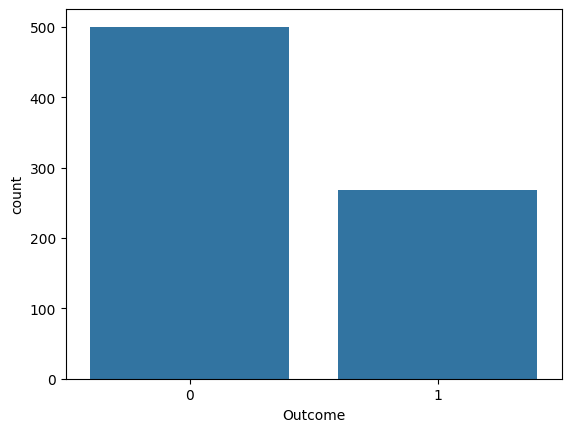

In [83]:
sns.countplot(x='Outcome', data=df)
plt.show()

In [84]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [86]:
scaler = StandardScaler()

In [87]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [88]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [89]:
y_pred_lr = lr.predict(X_test_scaled)

In [90]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [91]:
y_pred_rf = rf.predict(X_test)

In [92]:
print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Accuracy: 0.7077922077922078


In [93]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



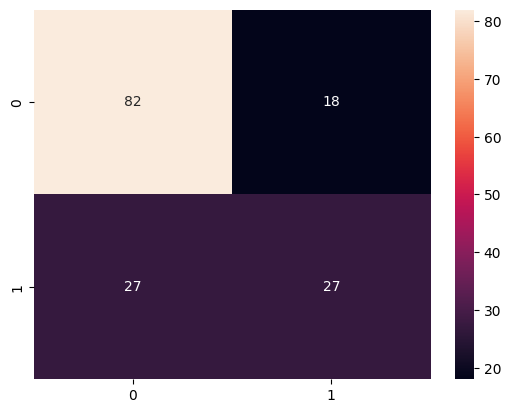

In [94]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [95]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7597402597402597


In [96]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



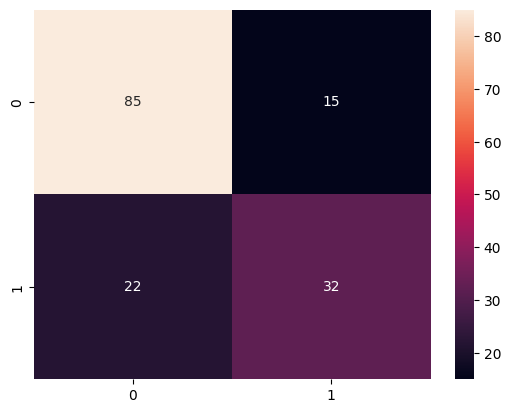

In [97]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [98]:
from imblearn.over_sampling import SMOTE

In [99]:
smote = SMOTE(random_state=42)

In [100]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [101]:
y_train_smote.value_counts()

Outcome
0    400
1    400
Name: count, dtype: int64

In [102]:
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [103]:
lr_smote = LogisticRegression()
lr_smote.fit(X_train_smote_scaled, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [104]:
y_pred_smote = lr_smote.predict(X_test_scaled)

In [105]:
print(accuracy_score(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

0.7142857142857143
              precision    recall  f1-score   support

           0       0.81      0.73      0.77       100
           1       0.58      0.69      0.63        54

    accuracy                           0.71       154
   macro avg       0.69      0.71      0.70       154
weighted avg       0.73      0.71      0.72       154



In [106]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Logistic + SMOTE'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_smote)
    ]
})

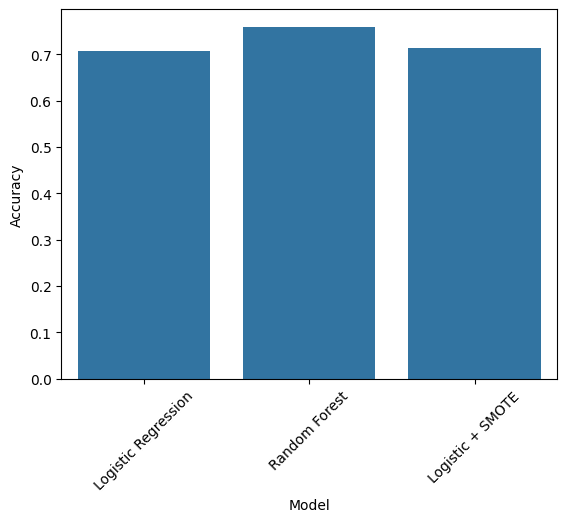

In [107]:
sns.barplot(x='Model', y='Accuracy', data=results)
plt.xticks(rotation=45)
plt.show()

# Random Oversampling

In [108]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

X_train_ros_scaled = scaler.fit_transform(X_train_ros)

lr_ros = LogisticRegression()

lr_ros.fit(X_train_ros_scaled, y_train_ros)

y_pred_ros = lr_ros.predict(X_test_scaled)

acc_ros = accuracy_score(y_test, y_pred_ros)

print(classification_report(y_test, y_pred_ros))
print("Random Oversampling Accuracy:", acc_ros * 100)

              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

Random Oversampling Accuracy: 73.37662337662337


#  Random Undersampling

In [109]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

X_train_rus_scaled = scaler.fit_transform(X_train_rus)

lr_rus = LogisticRegression()

lr_rus.fit(X_train_rus_scaled, y_train_rus)

y_pred_rus = lr_rus.predict(X_test_scaled)

acc_rus = accuracy_score(y_test, y_pred_rus)

print(classification_report(y_test, y_pred_rus))
print("Random Undersampling Accuracy:", acc_rus * 100)

              precision    recall  f1-score   support

           0       0.85      0.73      0.78       100
           1       0.60      0.76      0.67        54

    accuracy                           0.74       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.74      0.75       154

Random Undersampling Accuracy: 74.02597402597402


# SMOTE

              precision    recall  f1-score   support

           0       0.81      0.73      0.77       100
           1       0.58      0.69      0.63        54

    accuracy                           0.71       154
   macro avg       0.69      0.71      0.70       154
weighted avg       0.73      0.71      0.72       154



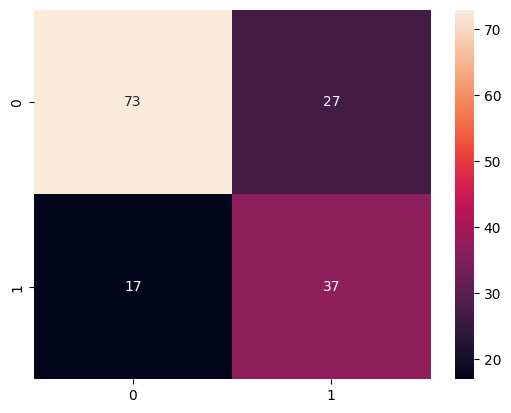

SMOTE Accuracy: 71.42857142857143


In [110]:
from imblearn.over_sampling import SMOTE
from seaborn import heatmap

smote = SMOTE(random_state=42)

# Apply SMOTE on training data only
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Scaling
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Train model
lr_smote = LogisticRegression()

lr_smote.fit(X_train_smote_scaled, y_train_smote)

# Prediction
y_pred_smote = lr_smote.predict(X_test_scaled)

# Accuracy
acc_smote = accuracy_score(y_test, y_pred_smote)

# Report
print(classification_report(y_test, y_pred_smote))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_smote)

heatmap(cm, annot=True, fmt='d')
plt.show()

print("SMOTE Accuracy:", acc_smote * 100)